In [2]:
import numpy as np
import matplotlib.pyplot as plt
from functions import lc_model

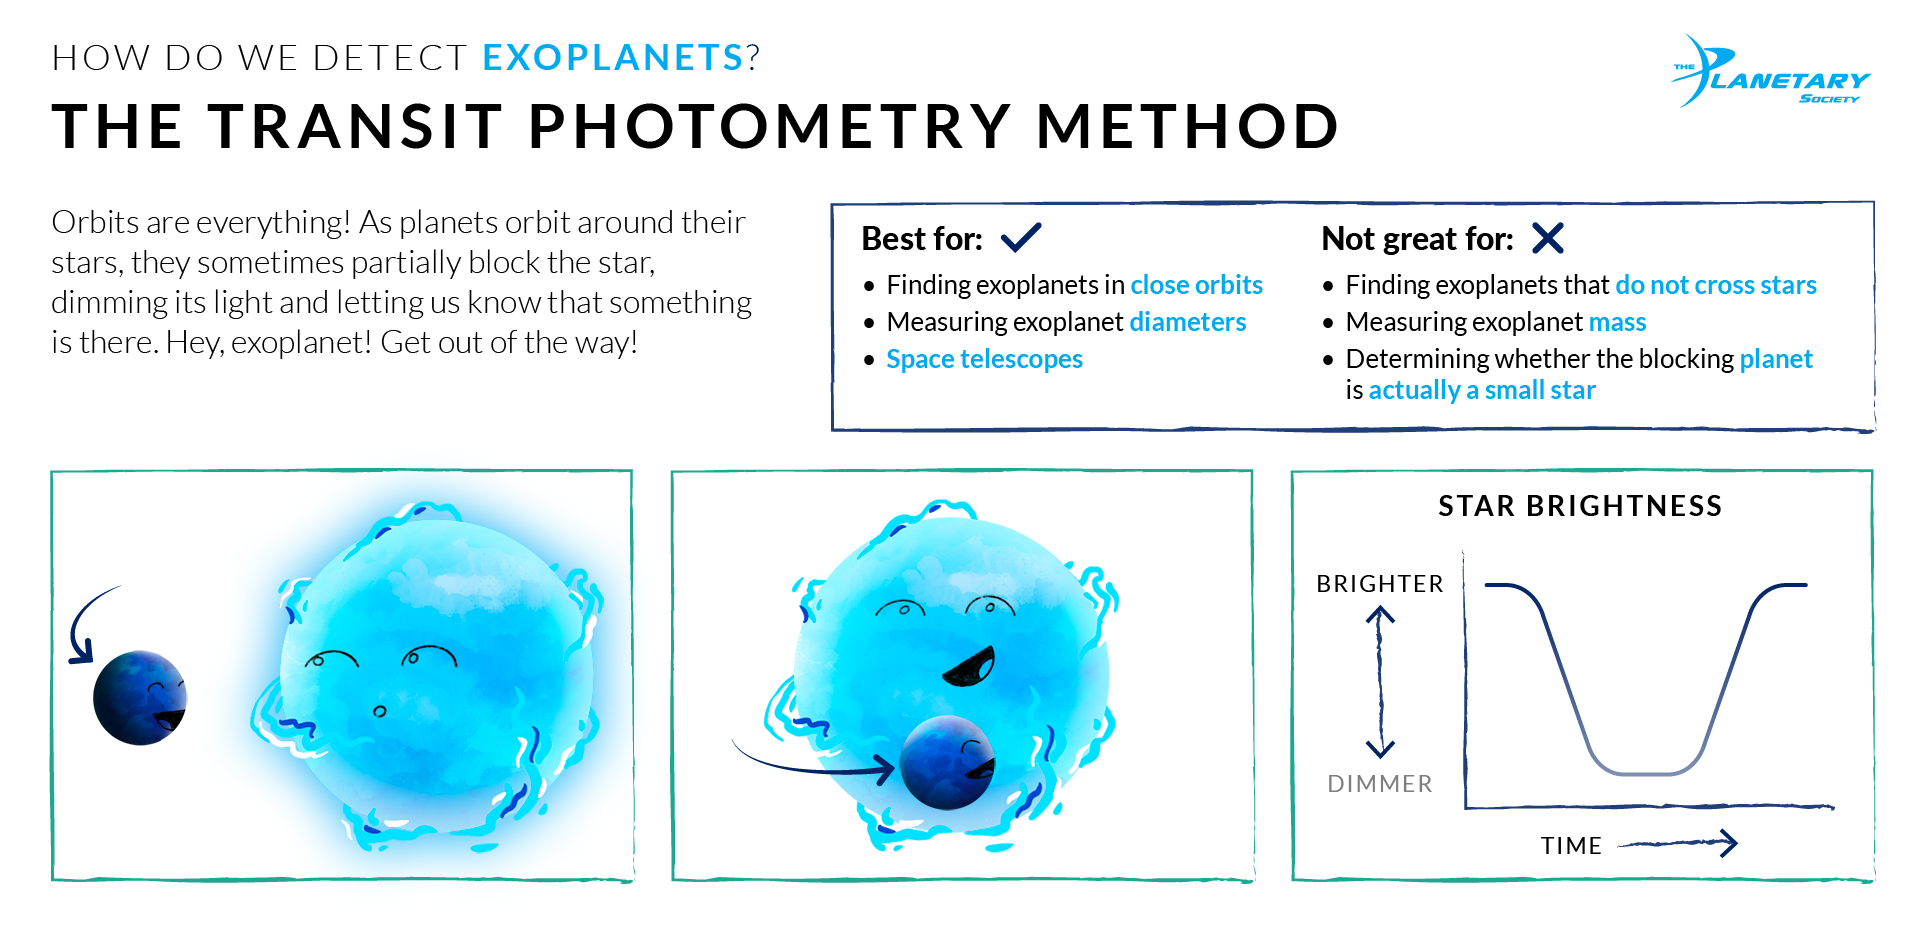

Transit photometry relies on a planet passing in front of its host star along an observers line of sight and blocking some of its light (i.e., casting a shadow on Earth). The fraction of light blocked, or the transit depth $\delta$ is determined by the ratio of the surface area of the planet to that of its star:

$$\Large \delta = f_0 \frac{\pi R_p^2}{\pi R_s^2} = f_0 \left(\frac{R_p}{R_s}\right)^2$$

where $f_0$ is the baseline flux of the host star. 

Flux is defined as 

$$\Large F = \frac{L}{4 \pi d^2}$$

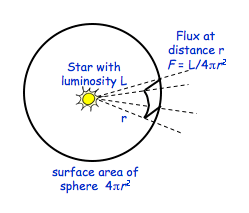


Where luminosity is the amount of light emitted per unit time. Transit light curves are generally normalized such that $f_0 = 1$. For someone on Earth to observe a tranist requires the planetary orbit to very nearly edge-on ($i \simeq \pi/2$). This is a low-probability event given that we can't know a priori what the inclination angle of a planet is (unless someone has observed it before) and it can take on any value between 0 and $\pi/2$ with uniform probability. As such, the transit photometry is most useful as a large survey like Kepler. The transit probability can be approximated by

$$\large p_{trans} \approx \frac{R_{S}}{a}$$

where $R_{S}$ is the radius of the star and $a$ is the semi-major axis of the planet. If someone was observing the Sun, what is the probability they would see Earth transit? Mercury? How about a planet at 0.01 AU?

OK, let's now assume we are lucky enough to observe a planetary transit and discuss the architecture of a transit light curve. Let's walk through the schematic below. 

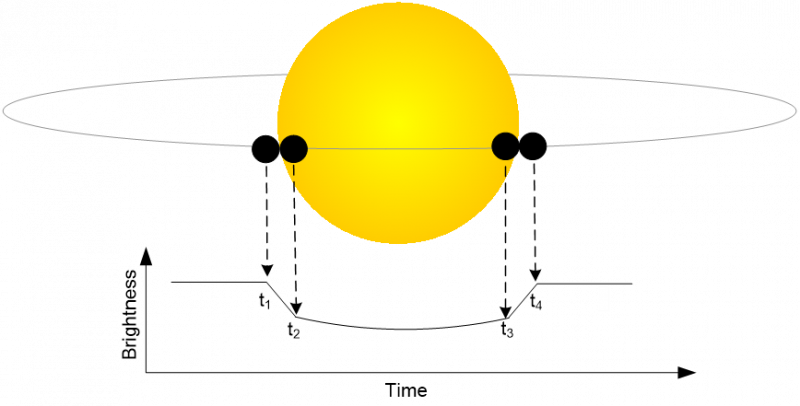

$t < t_1$: the is to the left of the stellar disk and is not blocking any of the star's light -- i.e., it has not yet begun to transit. The observed flux is just that of the star's and is a constant $f_0$. While there are variable stars that periodicically change in brightness (i.e., Omicron Ceti which you can see with the naked eye https://earthsky.org/brightest-stars/mira-quite-wonderful/), in general, the brightness of a star can be assumed to be constant. 

$t_1 < t < t_2$: this phase of the transit light curve is called 'ingress'. It is when the planet begins moving in front of the star blocking more and more of its light until it has moved fully in front of the star.

$t_2 < t < t_3$: at $t_2$ the planet is contained entirely within the disk of the star and it is blocking the maximum amount of light $\delta$. In this time frame the flux is a constant $f_0*\delta$.

$t_3 < t < t_4$: this phase of the transit is called 'egress'.

$t > t_4$: the planet is no longer blocking any of the star's light and the observed flux returns to $f_0$.

As such, when a planet is not transiting, its brightness or flux will remain constant. A transit is defined by the time frame when the planet begins blocking the star's light until it is no longer blocking light. 

The transit duration is defined as the amount of time the planet is blocking any amount of light. So, here $t_d \equiv t_4 - t_1$. The transit duration is primarily determined by the orbital period of the planet and the impact parameter.


### The impact parameter

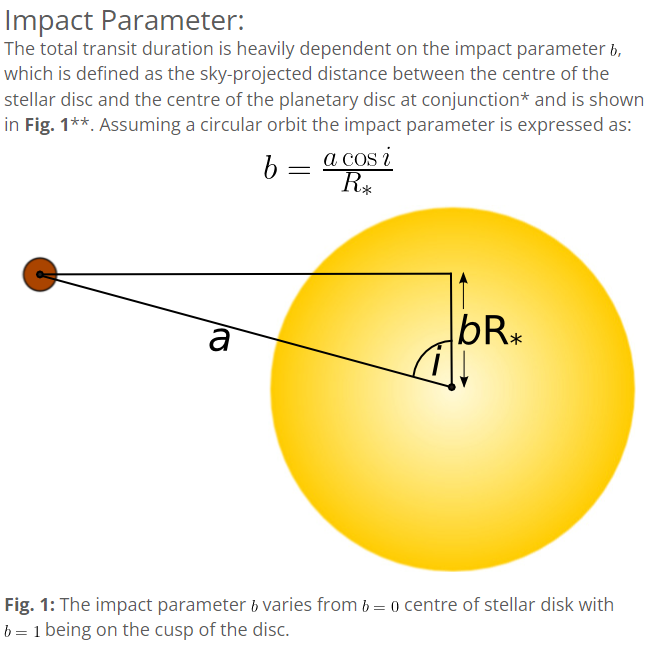


The impact parameter does not have to be less than 1. What happens if it exceedes 1? Play around with the plot below. What range of inclination angles result in a transit for a planet at 0.01, 0.1, and 1 AU?

51 Peg b has a semi-major axis of ~0.05 AU and estimated orbital inclination of 80 degrees. Does this planet transit?

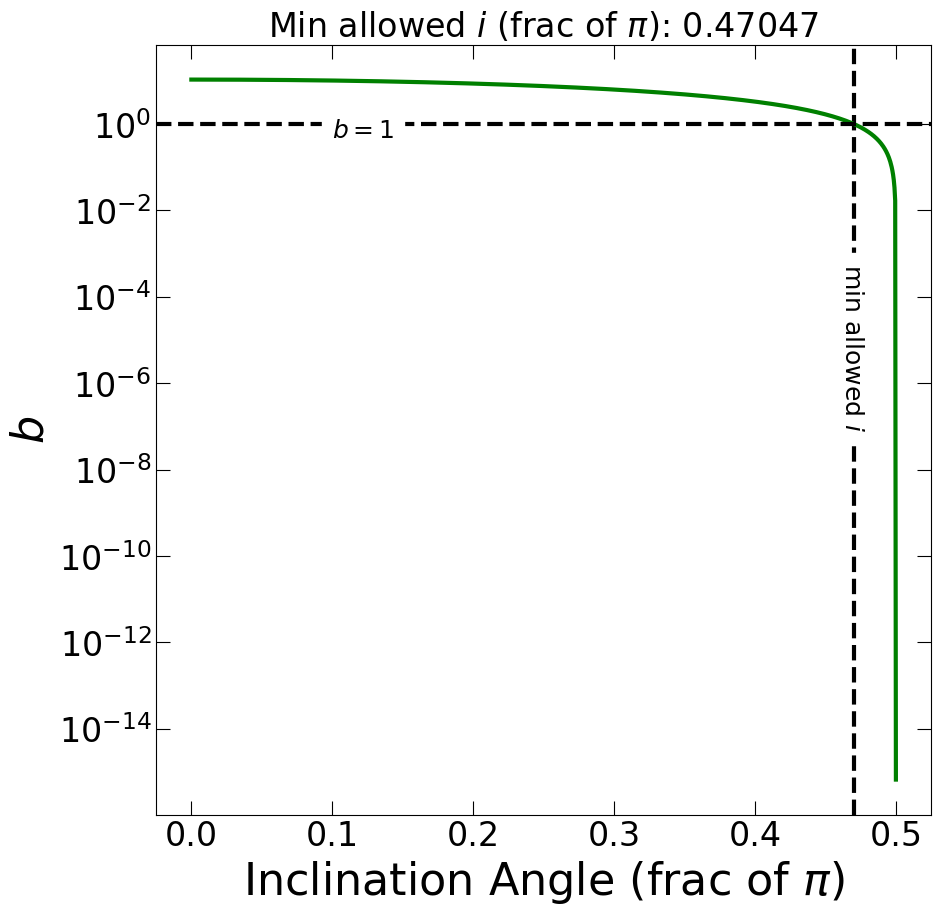

In [8]:
a = 0.05 #semi major axis in AU

plt.figure(figsize = (10,10))
angle = np.linspace(0, np.pi/2.0, 1000)
Rs = 0.00465047
b = a*np.cos(angle)/Rs

plt.tick_params(which = 'both', top = True, right = True, length = 10, direction = 'in', labelsize = 24)
plt.xlabel(r'Inclination Angle (frac of $\pi$)', fontsize = 32)
plt.ylabel(r'$b$', fontsize = 32)

ind = np.argmin(abs(b-1.0))
plt.title(r'Min allowed $i$ (frac of $\pi$): ' + str( round(angle[ind]/np.pi, 5)), fontsize = 24)

plt.axvline(angle[ind]/np.pi, color = 'k', lw = 3, ls = '--')
plt.plot(angle/np.pi, b, 'g-', lw = 3)
plt.text(0.1, 0.5, r'$b=1$', backgroundcolor = 'w', fontsize = 18)
plt.text(angle[ind]/np.pi - 0.01, 0.0000001, r'min allowed $i$', backgroundcolor = 'w', fontsize = 18, rotation = -90)

plt.axhline(1.0, color = 'k', lw = 3, ls = '--')
plt.yscale('log')
#plt.xscale('log')

### Light curve models
Now let's model some actual light curves! I'm using the function lc_model from the functions.py file. You don't need to worry about what it is doing, but for those curious, I'm implementing the transit approximation from this paper https://iopscience.iop.org/article/10.1086/592321/pdf

I have included a few pre-generated animations exploring the influences of inclination angle and planet radius in the folders below. Look through these and discuss the differences with your classmates.

- 'changes in radius': shows transit for $R_p = 1 \;R_\oplus, 5\; R_\oplus, \mathrm{and} \; 10 \; R_\oplus$ with $i = \pi/2$
- 'changes in inclination angle': shows $i = \pi/2, 0.9\times\pi/2, 0.8\times\pi/2, 0.7\times\pi/2$ for a $10 \; R_\oplus$ planet at 0.01 AU.
- 'changes in semi-major axis for slightly inclined orbit': I fixed $R_p = 10 R_\oplus$ and $i = 0.999\times\pi/2$ (so slightly inclined). The animations show a = 0.01, 0.1, 1.0,and 2.0 AU.


*** For transits close to grazing, the top and bottom animations don't quite line up. That is b/c the approximation I'm using gets worse as the impact parameter increases, but you should still be able to get the basic idea.

Feel free to play around with the input parameters and create your own animations:
- Planet radius: $R_p$ (in $R_\oplus$ units), 
- Stellar radius: $R_s$ (also in $R_\oplus$ units)
- semi-major axis: $a$ (in AU)
- inclination angle: $i$ (in radians)

Be careful with you choice of inclination angle. Make sure you stay below b=1 or the code will break. Also, the approximation I'm using gets less accurate as b approaches 1 (i.e., grazing transits) and the top and bottom panels of the animation may not line up exactly.

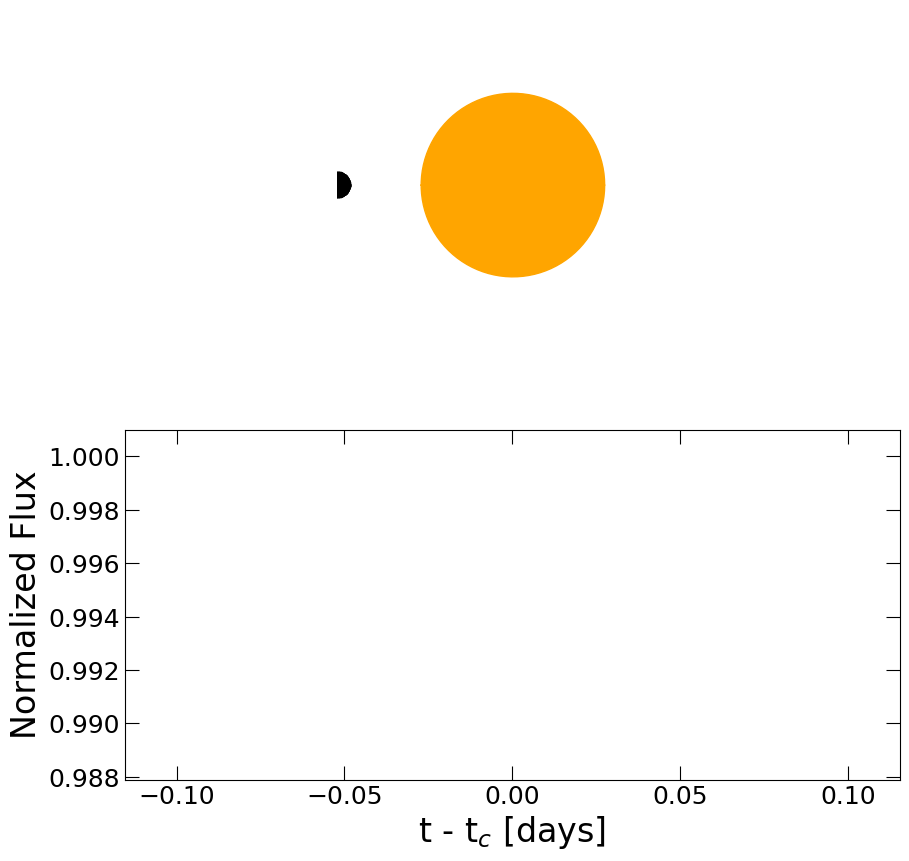

In [14]:
#input parameters
Rp = 10.0
Rs = 109.0
a = 0.05
#i = 1.0*np.pi/2.0
i = np.pi/2.0


from matplotlib.animation import FuncAnimation
import matplotlib.animation

fig, ax = plt.subplots(2,1, figsize = (10,10))


#may need to change
ax[1].set_ylim(1.0 - 0.11**2, 1.001)


flux, tt, tc, b, z = lc_model(Rp = Rp, Rs = Rs, a = a, inc = i, npts = 100)
ax[0].set_axis_off()

ax[0].set_xlim(-max(z), max(z))
ax[0].set_ylim(-max(z), max(z))
ax[0].set_aspect('equal', 'box')

ax[1].set_xlim(min(tt-tc), max(tt-tc))
ax[1].set_aspect('equal')

x = [1.0*np.cos(angle) for angle in np.linspace(0, 2*np.pi, 100)]
y = [1.0*np.sin(angle) for angle in np.linspace(0, 2*np.pi, 100)]
ax[0].fill_between(x, y, 'o', color = 'orange', lw = 1)

pl, = ax[0].plot([], [], marker = 'o', color = 'k', lw = 1)


l, = ax[1].plot([],[], 'k-', linewidth = 3);

ax[1].plot(tt-tc, flux, 'w-', linewidth = 0)

ax[1].set_xlim(min(tt-tc), max(tt-tc))
ax[1].set_aspect('auto','box')

ax[1].tick_params(which = 'both', top = True, right = True, direction = 'in', length = 10, labelsize = 18)
ax[1].set_xlabel(r't - t$_c$ [days]', fontsize = 24)
ax[1].set_ylabel(r'Normalized Flux', fontsize = 24)


sign = (tt-tc)/abs(tt-tc)


def animate(i):
    x = np.array([])
    y = np.array([])
    sign = (tt[i]-tc)/abs(tt[i]-tc)
    for angle in np.linspace(0, 2*np.pi, 30):
        for rad in np.linspace(Rp/Rs, 0.0, 30):
            x = np.append(x, sign*z[i] + rad*np.cos(angle))
            y = np.append(y, rad*np.sin(angle) + b)
    pl.set_data(x, y)

    l.set_data(tt[:i+1]-tc, flux[:i+1])

    plt.pause(0.0001)


ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(tt))

from IPython.display import HTML
HTML(ani.to_jshtml())


writer = matplotlib.animation.PillowWriter(fps=15,
                                 metadata=dict(artist='Me'),
                                 bitrate=1800)
gifname = 'Rp=' + str(round(Rp, 2)) + 'Re_' + 'Rs=' + str(round(Rs, 2)) + 'Re' +'_a=' + str(round(a, 2)) + 'AU' + '_i=' + str(round(i, 2)) + 'rad'
ani.save(gifname + '.gif', writer=writer)




In [ ]:
### Would like to add an adaptive resolution so its finer around the transit and poor outside of transit but 